
## Classification de Pneumonie avec ResNet50V2 + MLflow

## 📌 Présentation du Modèle

Le modèle utilisé est **ResNet50**, un réseau convolutif profond avec **connexions résiduelles**, pré-entraîné sur ImageNet. Il sert ici de **backbone** pour détecter la pneumonie à partir d’images radiographiques thoraciques.

### ✅ Pourquoi choisir ResNet50 ?

- **Apprentissage de caractéristiques complexes**  
  Grâce à ses **50 couches** et ses **blocs résiduels**, ResNet50 peut modéliser des **patrons visuels fins** dans les radios pulmonaires, ce qui est crucial pour distinguer des anomalies comme la pneumonie.

- **Stabilité et profondeur sans dégradation**  
  Les **connexions résiduelles (skip connections)** permettent de construire un réseau très profond sans perte de performance due à l’explosion ou disparition du gradient. Cela assure une **meilleure convergence** lors de l'entraînement.

- **Performance éprouvée en classification médicale**  
  ResNet50 est l’un des modèles les plus utilisés dans les compétitions et applications médicales pour la **détection d’anomalies sur imagerie**.

- **Transfert Learning optimal**  
  Son architecture permet de **réutiliser les couches convolutives** comme extracteurs de caractéristiques, tout en adaptant uniquement la tête du réseau à la tâche de **classification binaire (NORMAL vs PNEUMONIA)**.

- **Bon compromis complexité / performance**  
  Moins lourd que des architectures comme **ResNet101** ou **EfficientNet-B5**, ResNet50 reste **efficace** et **relativement rapide** à entraîner sur des machines standards.



### 📦 1. Importation des bibliothèques nécessaires

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
# 🔍 Suivi avec MLflow
import mlflow
import mlflow.tensorflow

In [ ]:
# 🔧 Configuration de MLflow
mlflow.set_tracking_uri("http://localhost:5000")  # Définit l’URL du serveur MLflow pour le suivi des expériences
mlflow.set_experiment("pneumonia_classification") # Définit le nom de l’expérience MLflow (créée si elle n’existe pas)

# 📁 Création du dossier pour artefacts (confusion matrix, courbes, etc.)
ARTIFACT_DIR = "artifacts"                        # Nom du dossier où seront stockés les artefacts (images, courbes, etc.)
os.makedirs(ARTIFACT_DIR, exist_ok=True)          # Crée le dossier s’il n’existe pas déjà (évite une erreur si déjà présent)


### 📊 2. Préparation des données

In [ ]:



# 📂 Répertoires
TRAIN_DIR = "data/chest_xray/train"
VAL_DIR = "data/chest_xray/val"
TEST_DIR = "data/chest_xray/test"

# 📐 Paramètres d’image
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# 🔁 Augmentation des données pour l'entraînement
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# 📊 Normalisation simple pour val/test
val_test_datagen = ImageDataGenerator(rescale=1./255)

# 📦 Chargement des données
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False  # Important pour que les prédictions correspondent aux vraies classes
)

# 🏷️ Affichage des classes
print("Classes détectées:", train_generator.class_indices)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Classes détectées: {'NORMAL': 0, 'PNEUMONIA': 1}


### 🧠 3. Création du modèle basé sur ResNet50V2

In [ ]:

def create_model():
    # Chargement du modèle pré-entraîné sans la couche finale
    base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    base_model.trainable = False  # On "gèle" le modèle

    # Ajout des couches personnalisées
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# 🔨 Compilation
model = create_model()
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(), tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)


###  🚂 4. Entraînement du modèle + Tracking MLflow

In [ ]:
# Démarre une nouvelle expérience MLflow pour suivre ce run
with mlflow.start_run(run_name="resnet50v2_run"):

    # 🔍 Enregistrement des hyperparamètres utilisés pour l'entraînement
    mlflow.log_params({
        "batch_size": BATCH_SIZE,
        "img_height": IMG_HEIGHT,
        "img_width": IMG_WIDTH,
        "base_model": "ResNet50V2",
        "learning_rate": 0.001,
        "dropout_rate": 0.5
    })

    # 🧠 Entraînement du modèle avec early stopping et réduction du learning rate si la validation stagne
    history = model.fit(
        train_generator,
        epochs=10,
        validation_data=validation_generator,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)
        ]
    )

    # 📈 Log des métriques d'entraînement et de validation à chaque époque dans MLflow
    for epoch in range(len(history.history['accuracy'])):
        mlflow.log_metrics({
            "train_accuracy": history.history['accuracy'][epoch],
            "val_accuracy": history.history['val_accuracy'][epoch],
            "train_loss": history.history['loss'][epoch],
            "val_loss": history.history['val_loss'][epoch],
            "train_auc": history.history['auc'][epoch],
            "val_auc": history.history['val_auc'][epoch]
        }, step=epoch)

    # 💾 Sauvegarde du modèle entraîné dans MLflow pour une réutilisation ou un déploiement ultérieur
    mlflow.tensorflow.log_model(model, "model")


c:\Users\Utilisateur\Desktop\simplon_dev_ia\ML_Deeplearning\Projet_Transfer_Learning\.venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 225s 1s/step - accuracy: 0.8775 - auc: 0.9193 - loss: 0.3293 - precision: 0.9175 - recall: 0.9176 - val_accuracy: 0.7500 - val_auc: 0.9688 - val_loss: 0.5926 - val_precision: 0.6667 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.9475 - auc: 0.9818 - loss: 0.1472 - precision: 0.9631 - recall: 0.9662 - val_accuracy: 0.6875 - val_auc: 0.9688 - val_loss: 0.4873 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.9452 - auc: 0.9836 - loss: 0.1407 - precision: 0.9617 - recall: 0.9656 - val_accuracy: 0.7500 - val_auc: 0.9688 - val_loss: 0.6882 - val_precision: 0.6667 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.9540 - auc: 0.9872 - loss: 0.1197 - precision: 0.9703 - recall: 0.9677 - val_accuracy: 0.9375 - val_auc: 0.9688 - val_loss: 0.2563 -

2025/05/28 11:12:11 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/28 11:12:43 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run resnet50v2_run at: http://localhost:5000/#/experiments/845367305544761466/runs/70d7bd97f94849a59c3dc780c8eab3dd
🧪 View experiment at: http://localhost:5000/#/experiments/845367305544761466


 ### 🧪 5. Évaluation sur l'ensemble de test

20/20 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.8525 - auc: 0.6331 - loss: 0.5129 - precision: 0.4924 - recall: 0.6368

Résultats sur l'ensemble de test:
Accuracy: 0.8862
AUC: 0.9453
Precision: 0.8753
Recall: 0.9538
20/20 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step


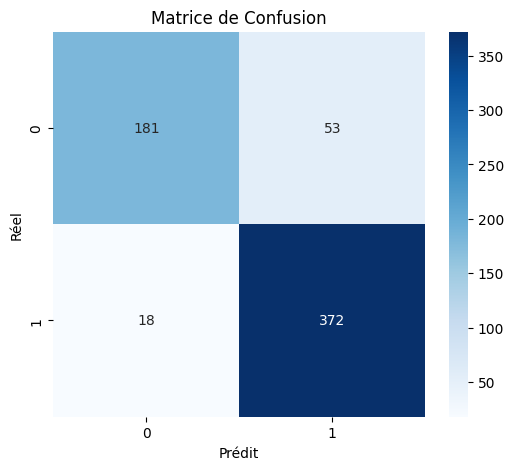

In [ ]:

    test_loss, test_accuracy, test_auc, test_precision, test_recall = model.evaluate(test_generator)
    print(f"\nRésultats sur l'ensemble de test:")
    print(f"Accuracy: {test_accuracy:.4f}")
    print(f"AUC: {test_auc:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall: {test_recall:.4f}")

    # 🔍 Prédictions
    y_pred_probs = model.predict(test_generator).ravel()
    y_preds = (y_pred_probs > 0.5).astype(int)
    y_true = test_generator.classes

    # 🔷 Matrice de confusion
    cm = confusion_matrix(y_true, y_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Matrice de Confusion")
    plt.ylabel("Réel")
    plt.xlabel("Prédit")
    cm_path = f"{ARTIFACT_DIR}/confusion_matrix.png"
    plt.savefig(cm_path)
    mlflow.log_artifact(cm_path)
    #plt.close()
    plt.show()


#### 📊 Matrice de Confusion

Le modèle distingue deux classes : **NORMAL (0)** et **PNEUMONIA (1)**, en comparant ses prédictions aux véritables étiquettes.

- Pour les cas réels **NORMAL (0)** :  
  - **181** prédictions correctes (**vrais négatifs**).  
  - **53** prédictions erronées classées comme pneumonie (**faux positifs**).

- Pour les cas réels **PNEUMONIA (1)** :  
  - **372** prédictions correctes (**vrais positifs**).  
  - **18** prédictions erronées classées comme normales (**faux négatifs**).

---

#### 🧠 Interprétation Nuancée (avec précautions médicales)

Même si le modèle montre des performances encourageantes sur cet échantillon, la taille relativement limitée du jeu de données implique de **rester très prudent** quant à ses conclusions.

- ✅ Le modèle détecte bien la pneumonie avec une majorité de cas positifs correctement identifiés, un point essentiel pour un dépistage rapide.
- ⚠️ Le **nombre de faux négatifs (18)** est faible, mais **chaque cas manqué peut avoir des conséquences graves**. La sécurité du patient doit rester la priorité.
- ⚖️ Les **faux positifs (53)** sont plus nombreux. Cela peut engendrer des examens supplémentaires, mais ce compromis est souvent jugé acceptable dans un système de triage.
- ❗ Les résultats peuvent **ne pas se généraliser** à d'autres populations, hôpitaux, ou appareils de radiologie.


👉 **Conclusion** : Le modèle semble prometteur pour la détection initiale de pneumonie, mais ses résultats doivent être confirmés avec un plus grand volume de données et en contexte clinique réel, avant de pouvoir le considérer comme fiable pour une utilisation systématique.



   ### 📊 Courbe ROC

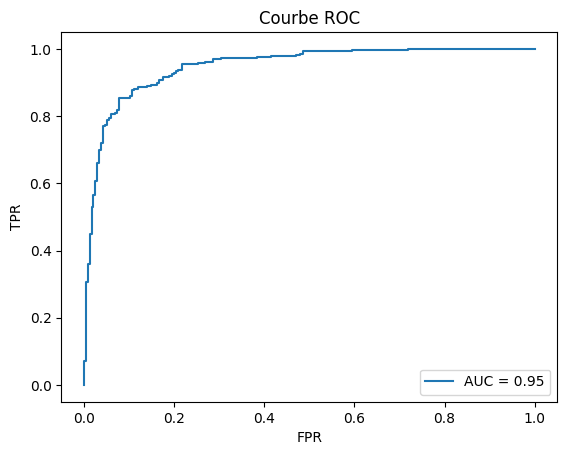

In [14]:

    # 📊 Courbe ROC
    fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
    plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.2f}")
    plt.title("Courbe ROC")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    roc_path = f"{ARTIFACT_DIR}/roc_curve.png"
    plt.savefig(roc_path)
    mlflow.log_artifact(roc_path)
    #plt.close()
    plt.show()


#### 📈 Interprétation de la courbe ROC et de l’AUC

La courbe ROC de ton modèle est **bien positionnée vers le coin supérieur gauche**, ce qui suggère qu’il distingue assez bien les cas positifs (pneumonie) des cas négatifs (normaux).

- **AUC (Area Under the Curve)** = **0.95**  
  - Une valeur proche de **1** indique généralement une **bonne capacité de discrimination** du modèle.  
  - Concrètement, cela signifie que le modèle a environ **95 % de chances** de classer correctement un cas positif devant un cas négatif.

✅ **Conclusion prudente sur la courbe** :  
Sur cet ensemble de validation, même s’il est limité (seulement 16 exemples), le modèle montre une **très bonne sensibilité et spécificité globales**. Ces résultats suggèrent que le modèle est prometteur pour la détection de pneumonie à partir de radiographies. Cependant, il est important de valider ces performances sur un jeu de données plus large et diversifié avant de considérer le modèle comme totalement fiable en contexte réel.


 #### 📊 Courbe Précision/Rappel

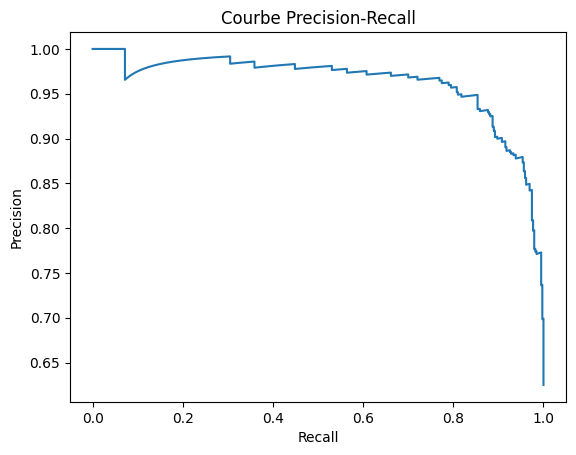

In [ ]:

    precision, recall, _ = precision_recall_curve(y_true, y_pred_probs)
    plt.plot(recall, precision)
    plt.title("Courbe Precision-Recall")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    pr_path = f"{ARTIFACT_DIR}/pr_curve.png"
    plt.savefig(pr_path)
    mlflow.log_artifact(pr_path)
    #plt.close()
    plt.show()


### 📉 6. Visualisation des courbes d'entraînement

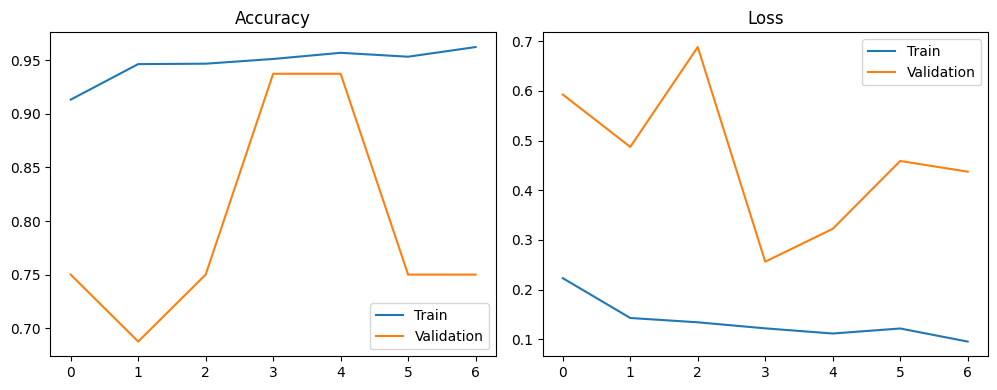

In [ ]:

    plt.figure(figsize=(15, 4))
    # Courbes d'accuracy
    plt.subplot(1, 3, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title("Accuracy")
    plt.legend()

    # Courbes de loss
    plt.subplot(1, 3, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title("Loss")
    plt.legend()

   

    plt.tight_layout()
    training_plot_path_ResNet50V2 = f"{ARTIFACT_DIR}/training_curves.png"
    plt.savefig(training_plot_path_ResNet50V2)
    mlflow.log_artifact(training_plot_path_ResNet50V2)
    #plt.close()
    plt.show()


### 📊 1. Analyse des courbes d'entraînement : Surapprentissage détecté

Les courbes d’accuracy et de loss montrent clairement un **problème de surapprentissage** à partir du milieu de l’entraînement.

#### 🔍 Accuracy (Précision)

- **Train Accuracy** : reste très élevée et stable (~0.95 à 0.97), ce qui indique que le modèle apprend **très bien les données d'entraînement**.
- **Validation Accuracy** : augmente fortement jusqu’à ~0.94 (vers l’epoch 3-4), puis **chute brutalement à ~0.75** à partir de l’epoch 5 → cela indique que le modèle commence à **mémoriser** les données d'entraînement au lieu de généraliser.

### 🔍 Loss (Fonction de perte)

- **Train Loss** : diminue de manière continue, ce qui est attendu en phase d’apprentissage.
- **Validation Loss** : diminue jusqu’à l’epoch 3, puis **remonte de manière significative**, un indicateur classique de **dégradation de la performance sur des données inconnues**.

---

#### ⚠️ Symptômes clairs de surapprentissage

- Écart croissant entre la précision entraînement/validation après l’epoch 4.
- Perte de validation qui remonte malgré une perte d'entraînement qui continue de baisser.
- Chute rapide de l'accuracy de validation malgré la bonne performance sur les données d'entraînement.


Le modèle **commence à surapprendre à partir de l’epoch 4**. Il devient trop adapté aux exemples qu’il a vus, ce qui **nuit à sa capacité à généraliser** à de nouvelles images.



## Conclusion 

#### ⚠️ Mise en garde essentielle sur l’usage médical

> **Ce modèle ne doit pas être utilisé seul en contexte clinique.**

- Il peut servir **d’assistant au diagnostic**, mais **jamais de substitut** au jugement d’un professionnel de santé.
- Toute mise en production nécessite :
  - Une **validation sur un grand échantillon multi-site**.
  - Un **audit éthique**.
  - Une **supervision médicale stricte**.
  - Des **mécanismes de retour d’expérience et de correction continue**.

---

#### 🚀  Recommandations pour la suite

- Élargir et diversifier le jeu de données.
- Mettre en place un mécanisme d’**early stopping** pour éviter le surapprentissage.
- Ajouter des techniques de **régularisation** (Dropout, L2).
- Intégrer des méthodes de validation croisée plus robustes.


---
#### Recommandations pour corriger le surapprentissage :

- ✅ **Early stopping** : arrêter l'entraînement quand la validation loss cesse de s'améliorer.
- ✅ **Data augmentation** : appliquer des transformations réalistes sur les radiographies (rotation, contraste, bruit).
- ✅ **Régularisation** : intégrer du dropout ou une pénalisation L2 pour limiter la complexité du modèle.
- ✅ **Réduction de la complexité du modèle** : simplifier la structure si elle est trop profonde ou surdimensionnée pour la taille du dataset.
- ✅ **K-fold cross-validation** : pour une évaluation plus robuste des performances générales du modèle.

> **Important** : En imagerie médicale, la généralisation est cruciale. Un modèle performant uniquement sur son jeu d'entraînement peut induire en erreur en pratique réelle.


#### 📌 Conclusion

Le modèle présente un **fort potentiel pour la détection initiale** de pneumonie sur radiographie. Néanmoins, il doit être **validé à plus grande échelle** et utilisé **avec prudence**, dans un cadre médical strictement encadré.
